In [1]:
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd

In [2]:
#********************************************************************************ACTIVE MODEL********************************************************************************

In [3]:
runs_eval_path = '/vision/asomaya1/active-rir/runs'
stats_file_name = 'test_telephone_stats_0.json'

#specify model to run
run = 'SD_A_1500_early_cooldown'

full_path = os.path.join(runs_eval_path, run, "tb", stats_file_name)


# Open and load the JSON file
with open(full_path, 'r') as json_file:
    data = json.load(json_file)

with open("/vision/asomaya1/active-rir/data/metadata/scene_sizes.json", "rb") as f:
    scene_sizes = json.load(f)

In [4]:
train_ep_count = {
    'D7N2EKCX4Sj': 63134,
    'XcA2TqTSSAj': 2586,
    'VLzqgDo317F': 18320,
    'aayBHfsNo7d': 8606,
    'jh4fc5c5qoQ': 2552,
    'gTV8FGcVJC9': 17552,
    'p5wJjkQkbXX': 51870,
    '5q7pvUzZiYa': 11894,
    '7y3sRwLe3Va': 8774,
    'r1Q1Z4BcV1o': 65190,
    'vyrNrziPKCB': 332103,
    'ur6pFq6Qu1A': 88915,
    'S9hNv5qa7GM': 4381,
    'V2XKFyX4ASd': 2696,
    'VFuaQ6m2Qom': 23844,
    'sKLMLpTHeUy': 7860,
    '1LXtFkjw3qL': 4426,
    '1pXnuDYAj8r': 8726,
    'e9zR4mvMWw7': 3642,
    'b8cTxDM8gDG': 7604,
    'EDJbREhghzL': 2750,
    'GdvgFV5R1Z5': 126,
    'r47D5H71a5s': 11382,
    'mJXqzFtmKg4': 7474,
    'PX4nDJXEHrG': 32954,
    'ZMojNkEp431': 14728,
    'B6ByNegPMKs': 296035,
    'kEZ7cmS4wCh': 58158,
    'D7G3Y4RVNrH': 50,
    '2n8kARJN3HM': 47152,
    'JF19kD82Mey': 728,
    'pRbA3pwrgk9': 634,
    'Pm6F8kyY3z2': 1160,
    '5LpN3gDmAk7': 16894,
    'cV4RVeZvu5T': 888,
    'uNb9QFRL6hY': 6364,
    '8WUmhLawc2A': 2258,
    'YmJkqBEsHnH': 1088,
    's8pcmisQ38h': 1406,
    '759xd9YjKW5': 8174,
    'i5noydFURQK': 0,
    'JeFG25nYj2p': 2278,
    '82sE5b5pLXE': 760,
    'rPc6DW4iMge': 2008,
    'E9uDoFAP3SH': 375581,
    'ac26ZMwG7aT': 17691,
    'PuKPg4mmafe': 126067,
    'VVfe2KiqLaN': 5528,
    'JmbYfDe2QKZ': 194,
    'ULsKaCPVFJR': 946,
    'Vvot9Ly1tCj': 106461,
    'VzqfbhrpDEA': 46185,
    'HxpKQynjfin': 0,
    '29hnd4uzFmX': 1282,
    'Uxmj2M2itWa': 3046,
    'qoiz87JEwZ2': 4150,
    'SN83YJsR3w2': 52320,
    'sT4fr6TAbpF': 1084,
}


In [5]:
val_ep_count = {
    '2azQ1b91cZZ': 49,
    '8194nk5LbLH': 14,
    'EU6Fwq7SyZv': 11,
    'QUCTc6BB5sX': 116,
    'TbHJrupSAjP': 7,
    'X7HyMhZNoso': 23,
    'Z6MFQCViBuw': 269,
    'oLBMNvg9in8': 5,
    'pLe4wQe7qrG': 2,
    'zsNo4HB9uLZ': 4
}

In [6]:
""" # Create the bar plot
plt.figure(figsize=(8, 3))  # You can adjust the figure size as needed
plt.bar(train_ep_count.keys(), train_ep_count.values())
plt.xlabel('Scene Name')
plt.ylabel('# Episodes')
plt.title('Episode Count Per Scene')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility

plt.show()

# Create the bar plot
plt.figure(figsize=(8, 3))  # You can adjust the figure size as needed
plt.bar(train_ep_count.keys(), [scene_sizes[key] for key in train_ep_count.keys()])
plt.xlabel('Scene Size')
plt.ylabel('# Episodes')
plt.title('Scene Sizes')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility

plt.show() """

" # Create the bar plot\nplt.figure(figsize=(8, 3))  # You can adjust the figure size as needed\nplt.bar(train_ep_count.keys(), train_ep_count.values())\nplt.xlabel('Scene Name')\nplt.ylabel('# Episodes')\nplt.title('Episode Count Per Scene')\nplt.xticks(rotation=90)  # Rotate x-axis labels for better visibility\n\nplt.show()\n\n# Create the bar plot\nplt.figure(figsize=(8, 3))  # You can adjust the figure size as needed\nplt.bar(train_ep_count.keys(), [scene_sizes[key] for key in train_ep_count.keys()])\nplt.xlabel('Scene Size')\nplt.ylabel('# Episodes')\nplt.title('Scene Sizes')\nplt.xticks(rotation=90)  # Rotate x-axis labels for better visibility\n\nplt.show() "

In [7]:
""" import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your data)
scene_names = train_ep_count.keys()
episode_count = list(train_ep_count.values())
scene_sizes = [scene_sizes[key] for key in scene_names]

# Set the width of the bars
bar_width = 0.35

# Create an array for the x-axis positions of the bars
x = np.arange(len(scene_names))

# Create the figure and axis objects
fig, ax = plt.subplots(figsize=(15, 6))

# Plot the episode count bars
bar1 = ax.bar(x - bar_width/2, [e for e in episode_count], bar_width, label='Episode Count')

# Plot the scene size bars
bar2 = ax.bar(x + bar_width/2, scene_sizes, bar_width, label='Scene Size')

# Set labels and title
ax.set_xlabel('Scene Name')
ax.set_ylabel('# Episodes / Scene Size')
ax.set_title('Episode Count and Scene Sizes Per Scene')
ax.set_xticks(x)
ax.set_xticklabels(scene_names, rotation=90)

# Add a legend
ax.legend()

# Display the plot
plt.tight_layout()
plt.show() """


" import matplotlib.pyplot as plt\nimport numpy as np\n\n# Example data (replace with your data)\nscene_names = train_ep_count.keys()\nepisode_count = list(train_ep_count.values())\nscene_sizes = [scene_sizes[key] for key in scene_names]\n\n# Set the width of the bars\nbar_width = 0.35\n\n# Create an array for the x-axis positions of the bars\nx = np.arange(len(scene_names))\n\n# Create the figure and axis objects\nfig, ax = plt.subplots(figsize=(15, 6))\n\n# Plot the episode count bars\nbar1 = ax.bar(x - bar_width/2, [e for e in episode_count], bar_width, label='Episode Count')\n\n# Plot the scene size bars\nbar2 = ax.bar(x + bar_width/2, scene_sizes, bar_width, label='Scene Size')\n\n# Set labels and title\nax.set_xlabel('Scene Name')\nax.set_ylabel('# Episodes / Scene Size')\nax.set_title('Episode Count and Scene Sizes Per Scene')\nax.set_xticks(x)\nax.set_xticklabels(scene_names, rotation=90)\n\n# Add a legend\nax.legend()\n\n# Display the plot\nplt.tight_layout()\nplt.show() "

In [8]:
import numpy as np
import pandas as pd

# Dictionary to store aggregated metrics for each scene
scene_metrics = {}

# Iterate through the dictionary and group metrics by scene
for key, metrics in data.items():
    # Split the key to extract the scene name
    parts = key.split('/')
    scene_name = parts[3]  # Assuming the scene name is always in the fourth position
    if scene_name not in scene_metrics:
        scene_metrics[scene_name] = {key: [] for key in metrics.keys()}
    # Append metrics to the scene-specific list
    for key in scene_metrics[scene_name]:
        scene_metrics[scene_name][key].append(metrics[key])

# Create a DataFrame to store the average metrics for each scene
average_scene_metrics = {}
stderr_scene_metrics = {}
for scene_name, metrics in scene_metrics.items():
    for key in metrics:
        if scene_name not in average_scene_metrics:
            average_scene_metrics[scene_name] = {}
            stderr_scene_metrics[scene_name] = {}
        average_scene_metrics[scene_name][key] = np.mean(metrics[key])
        stderr_scene_metrics[scene_name][key] = np.std(metrics[key]) / np.sqrt(len(metrics[key]))

# Create a DataFrame to store the number of episodes per scene
num_eps_per_scene = {}
for scene_name, metrics in scene_metrics.items():
    for key in metrics:
        if scene_name not in num_eps_per_scene:
            num_eps_per_scene[scene_name] = {}
        num_eps_per_scene[scene_name][key] = len(metrics[key])

# Create a DataFrame from the average metrics
df_average = pd.DataFrame(average_scene_metrics)

# Create a DataFrame from the number of episodes per scene
df_num_eps = pd.DataFrame(num_eps_per_scene)

# Display the average metrics as a table
print("Metrics Stratified by Scene:")
df_average


Metrics Stratified by Scene:


,fzynW3qQPVF,gxdoqLR6rwA,pa4otMbVnkk,gYvKGZ5eRqb,UwV83HsGsw3,5ZKStnWn8Zo,wc2JMjhGNzB,ARNzJeq3xxb,q9vSo1VnCiC,Vt2qJdWjCF2,yqstnuAEVhm,jtcxE69GiFV
reward,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
stft_l1_distance,0.010890,0.013675,0.017627,0.017472,0.018690,0.019860,0.018745,0.022541,0.014355,0.012062,0.016665,0.016714
diff_rt_startFrom60dB,0.164912,0.087196,0.062406,0.052451,0.046550,0.063353,0.114794,0.104408,0.104403,0.040014,0.022975,0.036956
rel_diff_rt_startFrom60dB,1.471352,0.178363,0.263058,0.100292,0.196061,0.368338,2.117659,0.701631,2.750754,0.127761,0.151788,0.207753
rel_diff_edt,1.011807,0.854870,0.600386,0.727411,0.966488,0.802342,0.952752,0.713131,0.675770,0.587897,0.638595,0.523631
diff_drr_3ms,27.148469,20.312063,45.889660,9.268751,14.143415,25.544090,78.397604,9.161135,53.861726,10.784671,20.293063,18.577525
rel_diff_drr_3ms,11.973196,2.786644,1.360967,4.951915,4.220075,1.111178,1.739902,1.393158,1.774926,2.587082,4.163868,1.833760


In [9]:
list(df_average.index)

['reward',
 'stft_l1_distance',
 'diff_rt_startFrom60dB',
 'rel_diff_rt_startFrom60dB',
 'rel_diff_edt',
 'diff_drr_3ms',
 'rel_diff_drr_3ms']

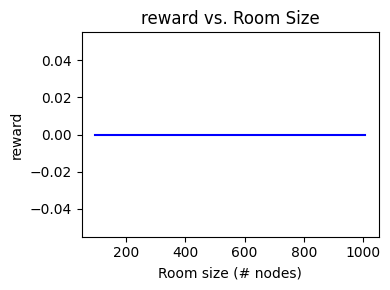

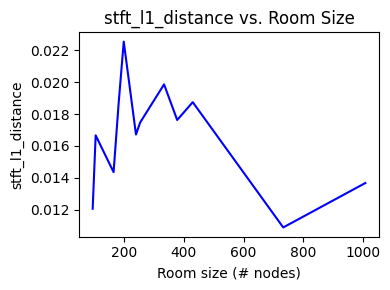

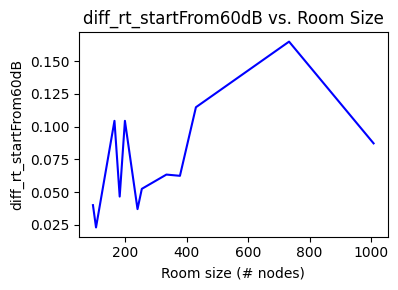

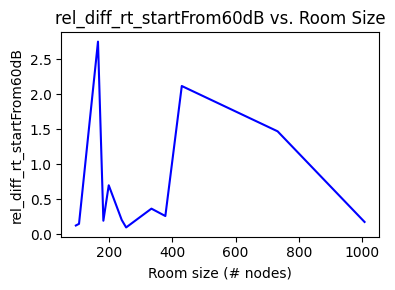

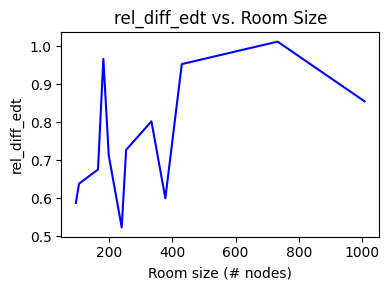

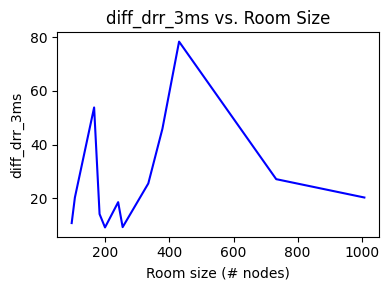

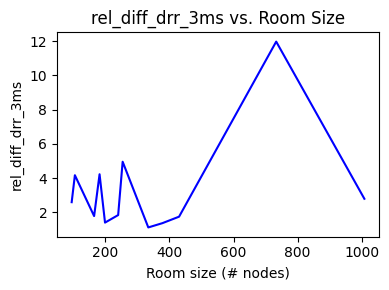

In [10]:
# Create scatter plots for each metric as a function of the integer
metrics_to_plot = list(df_average.index)

for metric in metrics_to_plot:
    # Extract metric values for all scenes
    metric_values = [average_scene_metrics[scene][metric] for scene in average_scene_metrics]
    integers = [scene_sizes[scene] for scene in average_scene_metrics]

    sorted_data = sorted(zip(integers, metric_values), key=lambda x: x[0])
    sorted_integers, sorted_metric_values = zip(*sorted_data)

    plt.figure(figsize=(4, 3))  # Adjust the figsize if needed
    plt.plot(sorted_integers, sorted_metric_values, linestyle='-', color='b')  # Line connecting points
    plt.xlabel('Room size (# nodes)')
    plt.ylabel(metric)
    plt.title(f'{metric} vs. Room Size')
    plt.tight_layout()
    plt.show()

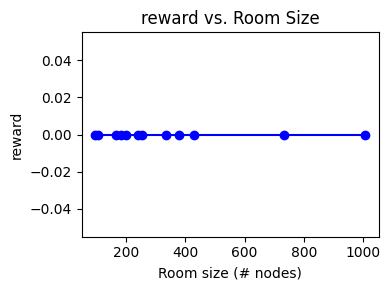

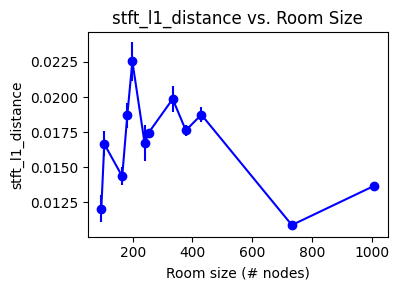

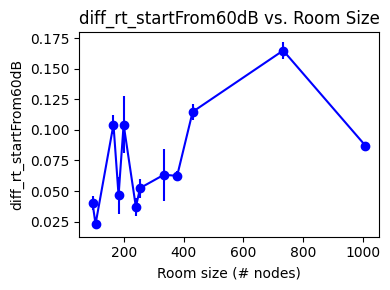

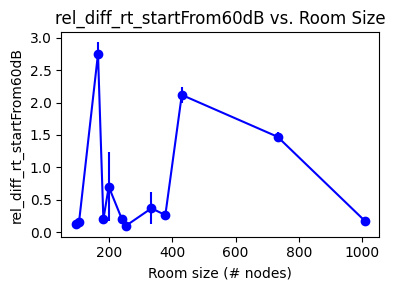

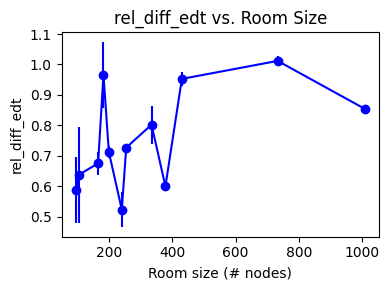

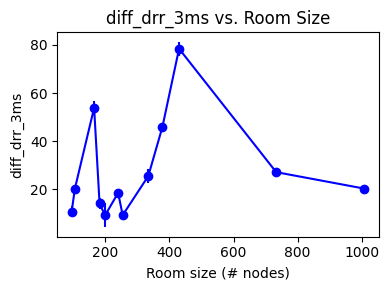

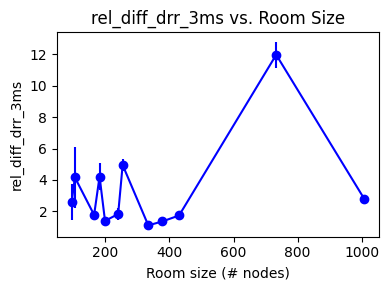

In [11]:
import matplotlib.pyplot as plt

for metric in metrics_to_plot:
    # Extract metric values and standard errors for all scenes
    metric_values = [average_scene_metrics[scene][metric] for scene in average_scene_metrics]
    stderr_values = [stderr_scene_metrics[scene][metric] for scene in stderr_scene_metrics]
    integers = [scene_sizes[scene] for scene in average_scene_metrics]

    sorted_data = sorted(zip(integers, metric_values, stderr_values), key=lambda x: x[0])
    sorted_integers, sorted_metric_values, sorted_stderr_values = zip(*sorted_data)

    plt.figure(figsize=(4, 3))  # Adjust the figsize if needed

    # Create a line graph with error bars for standard errors
    plt.errorbar(sorted_integers, sorted_metric_values, yerr=sorted_stderr_values, linestyle='-', marker='o', color='b')

    plt.xlabel('Room size (# nodes)')
    plt.ylabel(metric)
    plt.title(f'{metric} vs. Room Size')
    plt.tight_layout()
    plt.show()

In [12]:
results = {}
round_val = 8

first_episode_name = list(data.keys())[0]

for key in data[first_episode_name].keys():
    values = [inner_dict[key] for inner_dict in data.values()]
    mean = np.mean(values)
    median = np.median(values)
    std = np.std(values)

    results[key] = {'mean': np.round(mean, round_val), 'median': np.round(median, round_val), 'std': np.round(std, round_val)}

df = pd.DataFrame(results)
df = df.T
df

,mean,median,std
reward,0.000000,0.000000,0.000000
stft_l1_distance,0.013502,0.012666,0.003872
diff_rt_startFrom60dB,0.115179,0.072578,0.096913
rel_diff_rt_startFrom60dB,0.844201,0.336859,1.106486
rel_diff_edt,0.890423,0.863051,0.219553
diff_drr_3ms,26.518500,22.027395,14.667235
rel_diff_drr_3ms,6.400870,2.615014,10.179020


In [13]:
#********************************************************************************FS-RIR MODEL********************************************************************************

In [14]:
active_test_scene_names = """5ZKStnWn8Zo
ARNzJeq3xxb
fzynW3qQPVF
gxdoqLR6rwA
gYvKGZ5eRqb
jtcxE69GiFV
pa4otMbVnkk
q9vSo1VnCiC
UwV83HsGsw3
Vt2qJdWjCF2
wc2JMjhGNzB
yqstnuAEVhm"""

# Split the data into a list of strings
active_test_scene_names = active_test_scene_names.split('\n')

#active_test_scene_names = ['fzynW3qQPVF']

In [15]:
test_scene_episode_counts_1000 = """
2023-10-11 16:53:30, INFO: Sampled 19 from 5ZKStnWn8Zo
2023-10-11 16:53:30, INFO: Sampled 10 from ARNzJeq3xxb
2023-10-11 16:53:31, INFO: Sampled 5 from UwV83HsGsw3
2023-10-11 16:53:31, INFO: Sampled 6 from Vt2qJdWjCF2
2023-10-11 16:53:31, INFO: Sampled 390 from fzynW3qQPVF
2023-10-11 16:53:31, INFO: Sampled 38 from gYvKGZ5eRqb
2023-10-11 16:53:31, INFO: Sampled 449 from gxdoqLR6rwA
2023-10-11 16:53:31, INFO: Sampled 4 from jtcxE69GiFV
2023-10-11 16:53:31, INFO: Sampled 34 from pa4otMbVnkk
2023-10-11 16:53:31, INFO: Sampled 17 from q9vSo1VnCiC
2023-10-11 16:53:31, INFO: Sampled 26 from wc2JMjhGNzB
2023-10-11 16:53:31, INFO: Sampled 2 from yqstnuAEVhm
"""

test_scene_episode_counts = """
2023-10-11 16:53:30, INFO: Sampled 19 from 5ZKStnWn8Zo
2023-10-11 16:53:30, INFO: Sampled 10 from ARNzJeq3xxb
2023-10-11 16:53:31, INFO: Sampled 5 from UwV83HsGsw3
2023-10-11 16:53:31, INFO: Sampled 6 from Vt2qJdWjCF2
2023-10-11 16:53:31, INFO: Sampled 326 from fzynW3qQPVF
2023-10-11 16:53:31, INFO: Sampled 38 from gYvKGZ5eRqb
2023-10-11 16:53:31, INFO: Sampled 213 from gxdoqLR6rwA
2023-10-11 16:53:31, INFO: Sampled 4 from jtcxE69GiFV
2023-10-11 16:53:31, INFO: Sampled 34 from pa4otMbVnkk
2023-10-11 16:53:31, INFO: Sampled 17 from q9vSo1VnCiC
2023-10-11 16:53:31, INFO: Sampled 26 from wc2JMjhGNzB
2023-10-11 16:53:31, INFO: Sampled 2 from yqstnuAEVhm
"""


test_scene_episode_counts_5k = """
2023-11-01 00:04:22, INFO: Sampled 19 from 5ZKStnWn8Zo                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 10 from ARNzJeq3xxb                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 5 from UwV83HsGsw3                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 6 from Vt2qJdWjCF2                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 50 from fzynW3qQPVF                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 38 from gYvKGZ5eRqb                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 50 from gxdoqLR6rwA                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 4 from jtcxE69GiFV                                                                                                                               
2023-11-01 00:04:22, INFO: Sampled 34 from pa4otMbVnkk                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 17 from q9vSo1VnCiC                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 26 from wc2JMjhGNzB                                                                                                                              
2023-11-01 00:04:22, INFO: Sampled 2 from yqstnuAEVhm 
"""

# Split the data into lines
lines = test_scene_episode_counts_5k.strip().split('\n')

# Create a dictionary to store the mappings
test_scene_episode_counts_dict = {}

# Iterate through each line and extract the number sampled and the string
for line in lines:
    parts = line.split('from ')
    if len(parts) == 2:
        number_sampled = int(parts[0].split()[-1].strip())
        string_after_from = parts[1].strip()
        test_scene_episode_counts_dict[string_after_from] = number_sampled

# Print the resulting dictionary
print(test_scene_episode_counts_dict)

{'5ZKStnWn8Zo': 19, 'ARNzJeq3xxb': 10, 'UwV83HsGsw3': 5, 'Vt2qJdWjCF2': 6, 'fzynW3qQPVF': 50, 'gYvKGZ5eRqb': 38, 'gxdoqLR6rwA': 50, 'jtcxE69GiFV': 4, 'pa4otMbVnkk': 34, 'q9vSo1VnCiC': 17, 'wc2JMjhGNzB': 26, 'yqstnuAEVhm': 2}


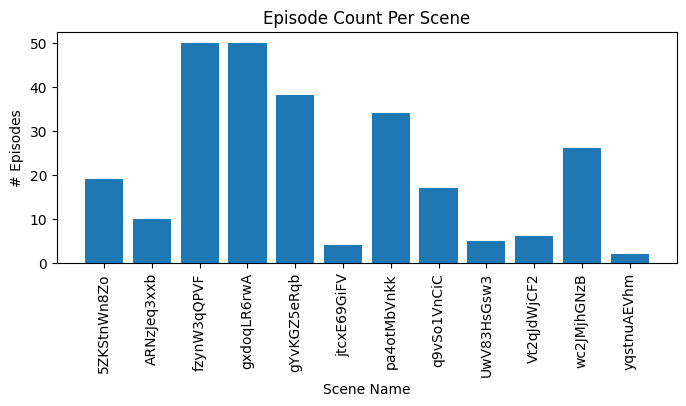

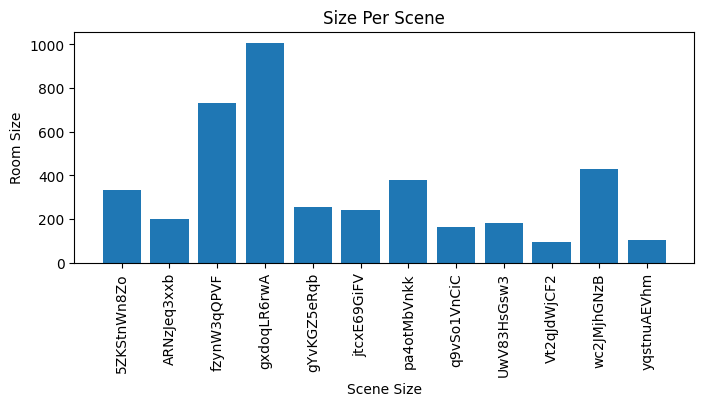

In [16]:
scenes_to_eval = active_test_scene_names
#keys = list(test_scene_episode_counts_dict.keys())
values = [test_scene_episode_counts_dict[key] for key in scenes_to_eval]
scene_size_values = [scene_sizes[key] for key in scenes_to_eval]

# Create the bar plot
plt.figure(figsize=(8, 3))  # You can adjust the figure size as needed
plt.bar(scenes_to_eval, values)
plt.xlabel('Scene Name')
plt.ylabel('# Episodes')
plt.title('Episode Count Per Scene')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility

plt.show()

# Create the bar plot
plt.figure(figsize=(8, 3))  # You can adjust the figure size as needed
plt.bar(scenes_to_eval, scene_size_values)
plt.xlabel('Scene Size')
plt.ylabel('Room Size')
plt.title('Size Per Scene')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility

plt.show()


In [17]:
dir_path = "/vision/asomaya1/active-rir/runs_eval/fs_rir"

with open(os.path.join(dir_path, "unseen_eval_364datapoints_metrics.pkl"), "rb") as f:
    metric_data = pickle.load(f)

with open(os.path.join(dir_path, "unseen_eval_364datapoints_sceneNames.pkl"), "rb") as f:
    scene_names = pickle.load(f)

with open("/vision/asomaya1/active-rir/data/metadata/scene_sizes.json", "rb") as f:
    scene_to_room_size = json.load(f)

In [18]:
from collections import defaultdict

scene_statistics = {}
active_metric_data = defaultdict(list)
# Iterate through unique scene names in your_scene_names
for scene_name in set(scene_names):
    if scene_name in active_test_scene_names:
        scene_indices = [i for i, name in enumerate(scene_names) if name == scene_name][:test_scene_episode_counts_dict[scene_name]]
    else:
        scene_indices = [i for i, name in enumerate(scene_names) if name == scene_name]
    room_size = scene_to_room_size.get(scene_name, None)  # Get the room size, if available
    num_episodes = len(scene_indices)
    
    if room_size is not None:
        scene_metric_values = {}
        
        # Calculate statistics for each metric
        for metric_name, metric_values in metric_data.items():
            scene_metric_values[metric_name] = {
                'mean': np.mean([metric_values[i] for i in scene_indices]),
                'median': np.median([metric_values[i] for i in scene_indices]),
                'std': np.std([metric_values[i] for i in scene_indices]),
            }
            if scene_name in active_test_scene_names:
                active_metric_data[metric_name].extend([metric_values[i] for i in scene_indices])
        
        # Store the scene statistics in the scene_statistics dictionary
        scene_statistics[scene_name] = {
            'num_episodes': num_episodes,
            'room_size': room_size,
            'metrics': scene_metric_values
        }

In [19]:
import pandas as pd

scenes_to_eval = active_test_scene_names
#scenes_to_eval = list(set(scene_names)) #eval all scenes

metric_type = "mean" #options: mean, median, std

""" for scene in scenes_to_eval:
    print(scene + " ({} episodes):".format(scene_statistics[scene]['num_episodes']))
    for metric in scene_statistics[scene]['metrics']:
        print(metric+":", scene_statistics[scene]['metrics'][metric][metric_type])
    print() """

result_df = pd.DataFrame()

# Iterate over scenes in scenes_to_eval
for scene in scenes_to_eval:
    result_df.at[scene, "num_episodes"] = int(scene_statistics[scene]['num_episodes'])
    scene_data = scene_statistics[scene]
    metrics_data = scene_data['metrics']
    
    for metric, values in metrics_data.items():
        mean_value = values['mean']
        result_df.at[scene, metric] = mean_value

result_df


,num_episodes,stft_l1_distance,diff_rt_startFrom60dB,diff_drr_3ms,rel_diff_rt_startFrom60dB,rel_diff_drr_3ms,diff_ratio_lrEnergy,rel_diff_edt
5ZKStnWn8Zo,19.0,0.011756,0.019770,0.782162,0.073064,0.189468,0.566626,0.200403
ARNzJeq3xxb,10.0,0.012859,0.004209,1.168203,0.008728,0.902564,1.028324,0.258236
fzynW3qQPVF,50.0,0.010935,0.197802,16.541474,0.506565,1.225380,1.687976,0.414169
gxdoqLR6rwA,50.0,0.015140,0.025773,19.909008,0.038043,0.776167,2.515527,0.260836
gYvKGZ5eRqb,38.0,0.011577,0.066889,3.350936,0.122459,0.552645,1.177584,0.206395
jtcxE69GiFV,4.0,0.014535,0.009008,1.639500,0.033286,0.275590,1.132593,0.223199
pa4otMbVnkk,34.0,0.015833,0.008437,9.636888,0.035334,0.435255,1.132382,0.215474
q9vSo1VnCiC,17.0,0.004846,0.597973,58.135689,12.712513,1.204876,1.986918,0.744246
UwV83HsGsw3,5.0,0.011164,0.005769,19.366674,0.025474,0.470286,1.944291,0.309566
Vt2qJdWjCF2,6.0,0.010186,0.039870,2.132672,0.071376,0.398179,1.139268,0.290365


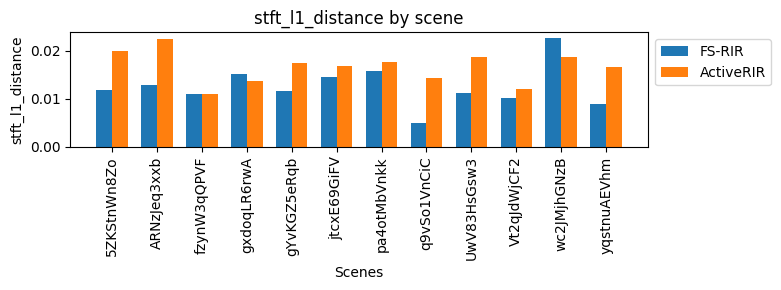

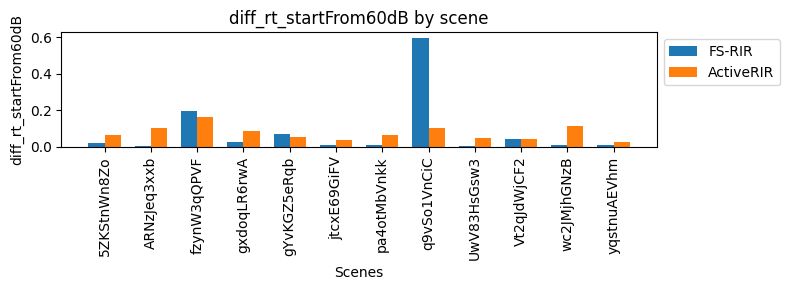

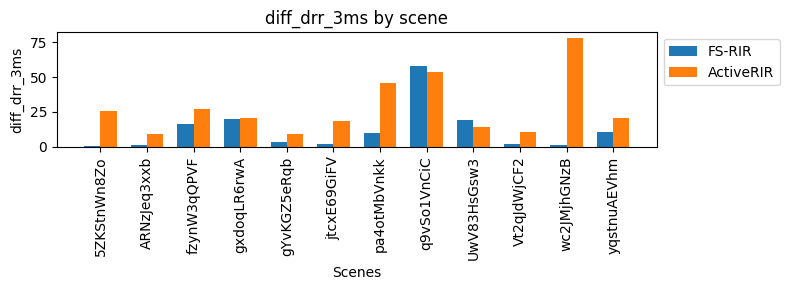

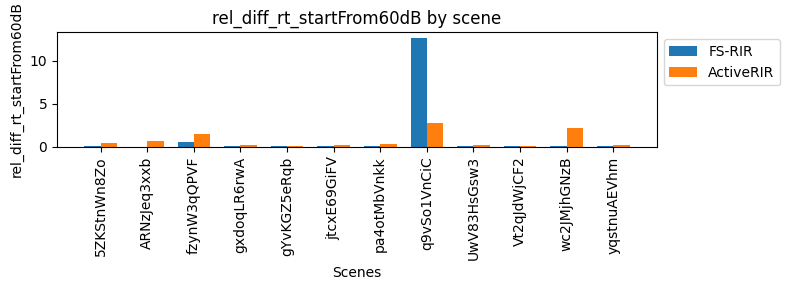

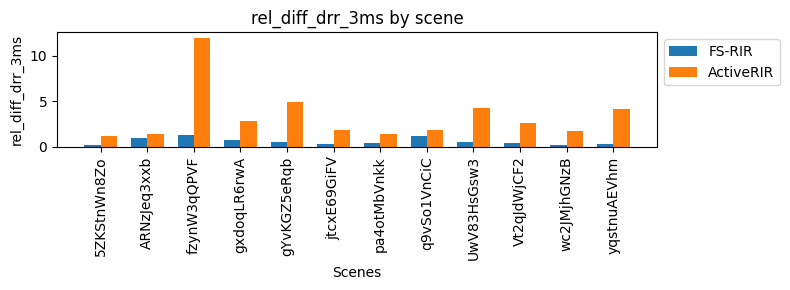

KeyError: 'diff_ratio_lrEnergy'

In [20]:
import matplotlib.pyplot as plt

metrics_to_plot = list(scene_statistics[next(iter(scene_statistics))]['metrics'].keys())

for metric in metrics_to_plot:
    metric_values_model1 = [scene_statistics[scene]['metrics'][metric]['mean'] for scene in scenes_to_eval]
    metric_values_model2 = [average_scene_metrics[scene][metric] for scene in scenes_to_eval]

    plt.figure(figsize=(8, 3))
    width = 0.35  # Bar width
    x = range(len(scenes_to_eval))

    plt.bar(x, metric_values_model1, width, label='FS-RIR')
    plt.bar([i + width for i in x], metric_values_model2, width, label='ActiveRIR')

    plt.xlabel('Scenes')
    plt.ylabel(metric)
    plt.title(f'{metric} by scene')
    plt.xticks([i + width / 2 for i in x], scenes_to_eval, rotation=90)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

In [ ]:
# Calculate test set statistics
test_set_statistics = {}
for metric_name, metric_values in active_metric_data.items():
    mean = np.mean(metric_values)
    median = np.median(metric_values)
    std = np.std(metric_values)
    test_set_statistics[metric_name] = {
        'mean': mean,
        'median': median,
        'std': std
    }
    
for metric in test_set_statistics.keys():
    print(f"Key: {metric}")
    print(f"Mean: {test_set_statistics[metric]['mean']}")

Key: stft_l1_distance
Mean: 0.013406818243819896
Key: diff_rt_startFrom60dB
Mean: 0.09624489942528736
Key: diff_drr_3ms
Mean: 13.256419289152616
Key: rel_diff_rt_startFrom60dB
Mean: 0.9663338032322805
Key: rel_diff_drr_3ms
Mean: 0.6905823868381373
Key: diff_ratio_lrEnergy
Mean: 1.5037407979029174
Key: rel_diff_edt
Mean: 0.3010503843223004


In [ ]:
""" #Compute mean metrics for across scenes as ActiveRIR test set
mean_metrics = {}

for scene in scenes_to_eval:
    key = scene
    value = scene_statistics[key]
    metrics = value['metrics']
    for metric, metric_data in metrics.items():
        if metric not in mean_metrics:
            mean_metrics[metric] = []
        mean_metrics[metric].append(metric_data['mean'])

# Calculate the mean for each metric across all dictionaries
for metric, values in mean_metrics.items():
    if metric_type == "mean":
        mean_metrics[metric] = np.sum(values) / len(values)
    elif metric_type == "median":
        mean_metrics[metric] = np.median(values) 
    else:
        mean_metrics[metric] = np.std(values)

mean_metrics """

In [ ]:
""" # Extract metric means and room sizes from scene statistics
metric_means = {metric_name: [] for metric_name in metric_data.keys()}
room_sizes = []

for scene_name, scene_data in scene_statistics.items():
    room_size = scene_data['room_size']
    room_sizes.append(room_size)
    
    for metric_name, metric_stats in scene_data['metrics'].items():
        metric_mean = metric_stats['mean']
        metric_means[metric_name].append(metric_mean)

# Create a bar plot for each metric
for metric_name, mean_values in metric_means.items():
    plt.figure()
    plt.scatter(room_sizes, mean_values)
    plt.xlabel('Room Size')
    plt.ylabel(metric_name + ' Mean')
    plt.title(metric_name + ' Mean vs. Room Size')
    plt.show() """